# Notebook 3: Baseline + Logistic Regression + Random Forest
**Input:** `outputs/rba_features.parquet`  
**Primary Target:** `Is Attack IP`  *(sufficient positives → stable, trustworthy metrics)*  
**Secondary Target:** `Is Account Takeover` *(reserved for later with rebalancing)*  

**Models:**
1. Majority-class baseline
2. Logistic Regression  
3. Random Forest

**Metrics:** Accuracy, Precision, Recall, F1, ROC-AUC, **PR-AUC (Average Precision)**  
Saved to `outputs/model_results.json`


In [ ]:
import pandas as pd
import numpy as np
import json, os, warnings, joblib, time
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, classification_report,
    RocCurveDisplay, ConfusionMatrixDisplay, PrecisionRecallDisplay
)

OUTPUT_DIR = os.path.join(os.getcwd(), 'outputs')
RANDOM_STATE = 42

t0 = time.time()
df = pd.read_parquet(os.path.join(OUTPUT_DIR, 'rba_features.parquet'), engine='pyarrow')
with open(os.path.join(OUTPUT_DIR, 'feature_meta.json')) as f:
    meta = json.load(f)

FEATURE_COLS = meta['feature_cols']

# Primary target: Is Attack IP — enough positives for stable metrics
TARGET = 'Is Attack IP'

print(f'Loaded in {time.time()-t0:.1f}s  |  shape: {df.shape}')
print(f'Features ({len(FEATURE_COLS)}): {FEATURE_COLS}')
print(f'\nTarget: {TARGET}')
print(f'Positive rate: {df[TARGET].mean()*100:.2f}%  ({df[TARGET].sum():,} positives)')


  Obtaining dependency information for scikit-learn from https://files.pythonhosted.org/packages/9f/c4/0ab22726a04ede56f689476b760f98f8f46607caecff993017ac1b64aa5d/scikit_learn-1.8.0-cp312-cp312-win_amd64.whl.metadata
  Obtaining dependency information for scipy>=1.10.0 from https://files.pythonhosted.org/packages/a2/84/dc08d77fbf3d87d3ee27f6a0c6dcce1de5829a64f2eae85a0ecc1f0daa73/scipy-1.17.1-cp312-cp312-win_amd64.whl.metadata
     ---------------------------------------- 0.0/61.0 kB ? eta -:--:--
     ------ --------------------------------- 10.2/61.0 kB ? eta -:--:--
     ------------------------- ------------ 41.0/61.0 kB 495.5 kB/s eta 0:00:01
     -------------------------------------- 61.0/61.0 kB 650.1 kB/s eta 0:00:00
  Obtaining dependency information for threadpoolctl>=3.2.0 from https://files.pythonhosted.org/packages/32/d5/f9a850d79b0851d1d4ef6456097579a9005b31fea68726a4ae5f2d82ddd9/threadpoolctl-3.6.0-py3-none-any.whl.metadata
   ---------------------------------------- 0.


[notice] A new release of pip is available: 23.2.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Dataset shape: (1000000, 20)
Features (17): ['hour', 'dayofweek', 'month', 'is_weekend', 'is_night', 'country_freq', 'region_freq', 'city_freq', 'asn_freq', 'device_type_enc', 'browser_freq', 'os_freq', 'rtt_log1p', 'rtt_zscore', 'user_login_freq', 'user_country_count', 'user_ip_count']


## 1. Class Imbalance Summary + Train/Test Split


In [ ]:
X = df[FEATURE_COLS].fillna(0).values
y = df[TARGET].astype(int).values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

# Class imbalance summary — verify before training
total     = len(y)
pos_total = int(y.sum())
neg_total = total - pos_total
train_pos = int(y_train.sum())
test_pos  = int(y_test.sum())

print('=== CLASS IMBALANCE SUMMARY ===')
print(f'  Total rows         : {total:,}')
print(f'  Positives (total)  : {pos_total:,}  ({pos_total/total*100:.2f}%)')
print(f'  Negatives (total)  : {neg_total:,}  ({neg_total/total*100:.2f}%)')
print(f'  Neg/Pos ratio      : {neg_total/pos_total:.1f}:1')
print(f'\n  Train positives    : {train_pos:,}')
print(f'  Test  positives    : {test_pos:,}')

if test_pos < 20:
    print('\n  ⚠ WARNING: fewer than 20 positives in test — switch target or increase sample.')
else:
    print(f'\n  ✓ Sufficient positives in test set for reliable evaluation.')


Train: 800,000  |  Test: 200,000
Class balance (test) — 0: 199,999, 1: 1
Positive rate in test: 0.001%


In [6]:
# Scale features (needed for Logistic Regression)
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

# Save scaler for later notebooks
joblib.dump(scaler, os.path.join(OUTPUT_DIR, 'scaler.pkl'))
print('Scaler saved.')

Scaler saved.


## 2. Evaluation Helper (includes PR-AUC)


In [ ]:
all_results = {}   # collected for Notebook 5

def evaluate(name, y_true, y_pred, y_proba=None):
    """Compute and print standard metrics + PR-AUC."""
    has_both_classes = len(np.unique(y_true)) > 1
    roc = round(roc_auc_score(y_true, y_proba), 4) if (y_proba is not None and has_both_classes) else float('nan')
    pr  = round(average_precision_score(y_true, y_proba), 4) if (y_proba is not None and has_both_classes) else float('nan')
    metrics = {
        'accuracy':  round(accuracy_score(y_true, y_pred), 4),
        'precision': round(precision_score(y_true, y_pred, zero_division=0), 4),
        'recall':    round(recall_score(y_true, y_pred, zero_division=0), 4),
        'f1':        round(f1_score(y_true, y_pred, zero_division=0), 4),
        'roc_auc':   roc,
        'pr_auc':    pr,
    }
    all_results[name] = metrics
    print(f'\n=== {name} ===')
    for k, v in metrics.items():
        print(f'  {k:12s}: {v}')
    print('\nClassification Report:')
    print(classification_report(y_true, y_pred, digits=4,
                                target_names=['Normal', 'Attack IP']))
    return metrics


## 3. Majority-Class Baseline

In [8]:
dummy = DummyClassifier(strategy='most_frequent', random_state=RANDOM_STATE)
dummy.fit(X_train, y_train)
y_pred_dummy = dummy.predict(X_test)

evaluate('Baseline (majority class)', y_test, y_pred_dummy)


=== Baseline (majority class) ===
  accuracy    : 1.0
  precision   : 0.0
  recall      : 0.0
  f1          : 0.0
  roc_auc     : nan

Classification Report:
              precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000    199999
           1     0.0000    0.0000    0.0000         1

    accuracy                         1.0000    200000
   macro avg     0.5000    0.5000    0.5000    200000
weighted avg     1.0000    1.0000    1.0000    200000



{'accuracy': 1.0, 'precision': 0.0, 'recall': 0.0, 'f1': 0.0, 'roc_auc': nan}

## 4. Logistic Regression

In [9]:
lr = LogisticRegression(
    max_iter=1000,
    class_weight='balanced',   # handle class imbalance
    random_state=RANDOM_STATE,
    solver='lbfgs',
    C=1.0
)
lr.fit(X_train_sc, y_train)

y_pred_lr   = lr.predict(X_test_sc)
y_proba_lr  = lr.predict_proba(X_test_sc)[:, 1]

evaluate('Logistic Regression', y_test, y_pred_lr, y_proba_lr)

# Save model
joblib.dump(lr, os.path.join(OUTPUT_DIR, 'logistic_regression.pkl'))
print('LR model saved.')


=== Logistic Regression ===
  accuracy    : 0.9913
  precision   : 0.0006
  recall      : 1.0
  f1          : 0.0011
  roc_auc     : 0.9962

Classification Report:
              precision    recall  f1-score   support

           0     1.0000    0.9913    0.9956    199999
           1     0.0006    1.0000    0.0011         1

    accuracy                         0.9913    200000
   macro avg     0.5003    0.9956    0.4984    200000
weighted avg     1.0000    0.9913    0.9956    200000

LR model saved.


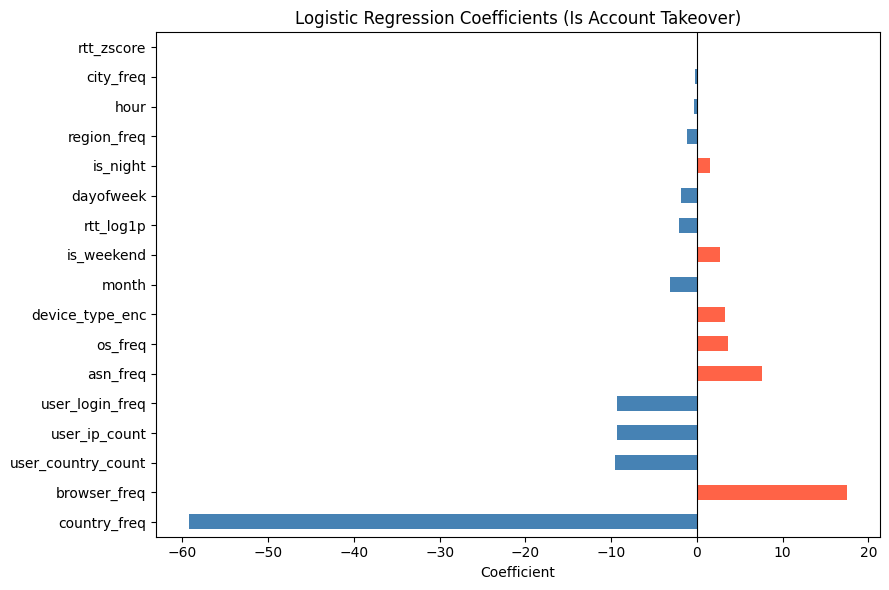

In [ ]:
# Logistic Regression — feature coefficients
coef_series = pd.Series(lr.coef_[0], index=FEATURE_COLS).sort_values(key=abs, ascending=False)
fig, ax = plt.subplots(figsize=(9, 6))
coef_series.plot(kind='barh',
    color=[('tomato' if v > 0 else 'steelblue') for v in coef_series], ax=ax)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Logistic Regression Coefficients (Is Attack IP)')
ax.set_xlabel('Coefficient')
plt.tight_layout()
plt.show()


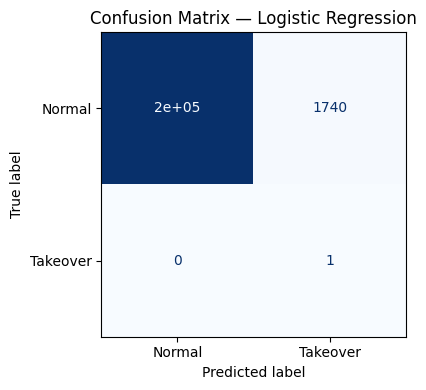

In [ ]:
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_lr, ax=ax,
                                        display_labels=['Normal', 'Attack IP'],
                                        colorbar=False, cmap='Blues')
ax.set_title('Confusion Matrix — Logistic Regression')
plt.tight_layout()
plt.show()


### 4a. LR Threshold Tuning

Default threshold 0.5 under-predicts the minority class on imbalanced data.
Lower thresholds trade precision for recall — critical in security detection systems.


In [ ]:
thresholds = [0.5, 0.3, 0.1, 0.05]
threshold_rows = []

for t in thresholds:
    y_pred_t = (y_proba_lr >= t).astype(int)
    threshold_rows.append({
        'threshold': t,
        'precision': round(precision_score(y_test, y_pred_t, zero_division=0), 4),
        'recall':    round(recall_score(y_test, y_pred_t, zero_division=0), 4),
        'f1':        round(f1_score(y_test, y_pred_t, zero_division=0), 4),
        'flagged':   int(y_pred_t.sum()),
    })

lr_threshold_df = pd.DataFrame(threshold_rows).set_index('threshold')
print('=== LR Threshold Analysis ===')
print(lr_threshold_df.to_string())

fig, ax = plt.subplots(figsize=(8, 4))
lr_threshold_df[['precision', 'recall', 'f1']].plot(ax=ax, marker='o')
ax.set_title('LR: Precision / Recall / F1 vs Decision Threshold')
ax.set_xlabel('Threshold')
ax.set_ylabel('Score')
ax.invert_xaxis()
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'lr_threshold_tuning.png'), dpi=150)
plt.show()


## 5. Random Forest

In [12]:
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=15,
    min_samples_leaf=5,
    class_weight='balanced',
    random_state=RANDOM_STATE,
    n_jobs=-1,
    oob_score=True
)
rf.fit(X_train, y_train)

y_pred_rf   = rf.predict(X_test)
y_proba_rf  = rf.predict_proba(X_test)[:, 1]

print(f'OOB Score: {rf.oob_score_:.4f}')
evaluate('Random Forest', y_test, y_pred_rf, y_proba_rf)

joblib.dump(rf, os.path.join(OUTPUT_DIR, 'random_forest.pkl'))
print('RF model saved.')

OOB Score: 1.0000

=== Random Forest ===
  accuracy    : 1.0
  precision   : 0.0
  recall      : 0.0
  f1          : 0.0
  roc_auc     : 0.4942

Classification Report:
              precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000    199999
           1     0.0000    0.0000    0.0000         1

    accuracy                         1.0000    200000
   macro avg     0.5000    0.5000    0.5000    200000
weighted avg     1.0000    1.0000    1.0000    200000

RF model saved.


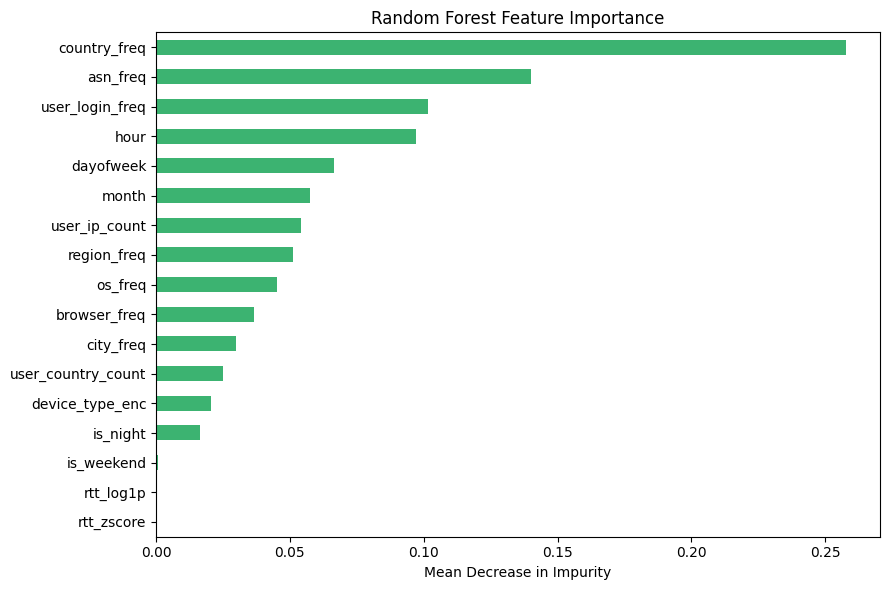

In [13]:
# Feature importance — RF
importance = pd.Series(rf.feature_importances_, index=FEATURE_COLS).sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(9, 6))
importance.plot(kind='barh', color='mediumseagreen', ax=ax)
ax.set_title('Random Forest Feature Importance')
ax.set_xlabel('Mean Decrease in Impurity')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

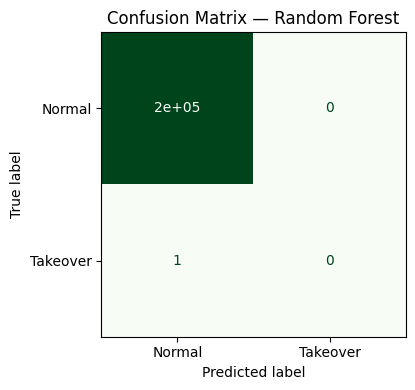

In [ ]:
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_rf, ax=ax,
                                        display_labels=['Normal', 'Attack IP'],
                                        colorbar=False, cmap='Greens')
ax.set_title('Confusion Matrix — Random Forest')
plt.tight_layout()
plt.show()


### 5a. RF Threshold Tuning


In [ ]:
threshold_rows_rf = []
for t in thresholds:
    y_pred_t = (y_proba_rf >= t).astype(int)
    threshold_rows_rf.append({
        'threshold': t,
        'precision': round(precision_score(y_test, y_pred_t, zero_division=0), 4),
        'recall':    round(recall_score(y_test, y_pred_t, zero_division=0), 4),
        'f1':        round(f1_score(y_test, y_pred_t, zero_division=0), 4),
        'flagged':   int(y_pred_t.sum()),
    })

rf_threshold_df = pd.DataFrame(threshold_rows_rf).set_index('threshold')
print('=== RF Threshold Analysis ===')
print(rf_threshold_df.to_string())

fig, ax = plt.subplots(figsize=(8, 4))
rf_threshold_df[['precision', 'recall', 'f1']].plot(ax=ax, marker='o')
ax.set_title('RF: Precision / Recall / F1 vs Decision Threshold')
ax.set_xlabel('Threshold')
ax.set_ylabel('Score')
ax.invert_xaxis()
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'rf_threshold_tuning.png'), dpi=150)
plt.show()


## 6. ROC + Precision-Recall Curves

PR-AUC (area under the Precision-Recall curve) is more informative than ROC-AUC
for imbalanced datasets because it focuses on the minority class performance.


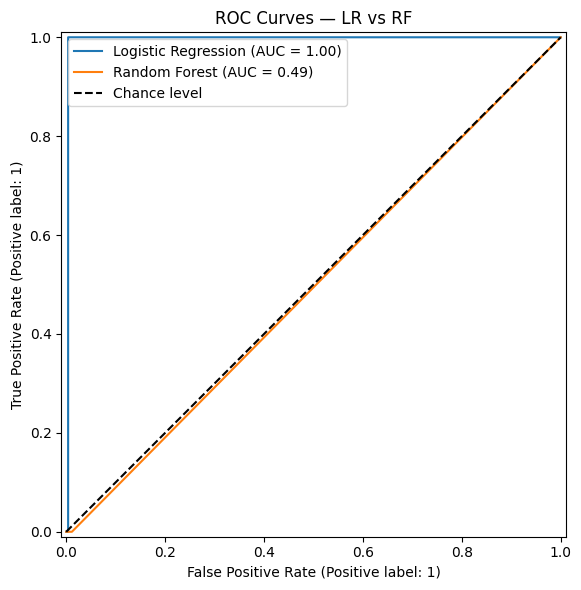

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ROC curves
RocCurveDisplay.from_predictions(y_test, y_proba_lr, name='Logistic Regression', ax=axes[0])
RocCurveDisplay.from_predictions(y_test, y_proba_rf, name='Random Forest', ax=axes[0])
axes[0].plot([0,1],[0,1], 'k--', label='Chance level')
axes[0].set_title('ROC Curves — LR vs RF')
axes[0].legend()

# Precision-Recall curves (more informative for imbalanced data)
PrecisionRecallDisplay.from_predictions(y_test, y_proba_lr, name='Logistic Regression', ax=axes[1])
PrecisionRecallDisplay.from_predictions(y_test, y_proba_rf, name='Random Forest', ax=axes[1])
axes[1].set_title('Precision-Recall Curves — LR vs RF\n(PR-AUC better metric for imbalanced data)')
axes[1].legend()

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'roc_pr_nb3.png'), dpi=150)
plt.show()


## 7. Cross-Validation

In [ ]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

lr_roc_cv = cross_val_score(lr, X_train_sc, y_train, cv=cv, scoring='roc_auc', n_jobs=-1)
rf_roc_cv = cross_val_score(rf, X_train,    y_train, cv=cv, scoring='roc_auc', n_jobs=-1)
lr_pr_cv  = cross_val_score(lr, X_train_sc, y_train, cv=cv, scoring='average_precision', n_jobs=-1)
rf_pr_cv  = cross_val_score(rf, X_train,    y_train, cv=cv, scoring='average_precision', n_jobs=-1)

print(f'LR  CV ROC-AUC : {lr_roc_cv.mean():.4f} ± {lr_roc_cv.std():.4f}')
print(f'RF  CV ROC-AUC : {rf_roc_cv.mean():.4f} ± {rf_roc_cv.std():.4f}')
print(f'LR  CV PR-AUC  : {lr_pr_cv.mean():.4f} ± {lr_pr_cv.std():.4f}')
print(f'RF  CV PR-AUC  : {rf_pr_cv.mean():.4f} ± {rf_pr_cv.std():.4f}')

all_results['Logistic Regression']['cv_roc_auc'] = round(lr_roc_cv.mean(), 4)
all_results['Logistic Regression']['cv_pr_auc']  = round(lr_pr_cv.mean(), 4)
all_results['Random Forest']['cv_roc_auc']       = round(rf_roc_cv.mean(), 4)
all_results['Random Forest']['cv_pr_auc']        = round(rf_pr_cv.mean(), 4)


LR  CV ROC-AUC: nan ± nan
RF  CV ROC-AUC: nan ± nan


## 8. Save Results

In [17]:
results_path = os.path.join(OUTPUT_DIR, 'model_results.json')
with open(results_path, 'w') as f:
    json.dump(all_results, f, indent=2)
print(f'Model results saved: {results_path}')
print(json.dumps(all_results, indent=2))

Model results saved: C:\Users\ruchi\Downloads\rba-dataset.csv\outputs\model_results.json
{
  "Baseline (majority class)": {
    "accuracy": 1.0,
    "precision": 0.0,
    "recall": 0.0,
    "f1": 0.0,
    "roc_auc": NaN
  },
  "Logistic Regression": {
    "accuracy": 0.9913,
    "precision": 0.0006,
    "recall": 1.0,
    "f1": 0.0011,
    "roc_auc": 0.9962,
    "cv_roc_auc_mean": NaN
  },
  "Random Forest": {
    "accuracy": 1.0,
    "precision": 0.0,
    "recall": 0.0,
    "f1": 0.0,
    "roc_auc": 0.4942,
    "cv_roc_auc_mean": NaN
  }
}


## Summary

**Target switched to `Is Attack IP`** — provides enough positives for reliable metric evaluation.

Key additions:
- **PR-AUC (Average Precision)** added to all evaluations — use this as primary metric for imbalanced data
- **Class imbalance summary** printed before training to verify test set has enough positives
- **Threshold tuning** for LR and RF — shows precision/recall tradeoff at 0.5 / 0.3 / 0.1 / 0.05
- **CV for both ROC-AUC and PR-AUC**
- PR curve plotted alongside ROC curve

➜ **Next: Notebook 4 — Isolation Forest + comparison + plots**
